# FarmTech Solutions — Fase 5

**Nome:** Cloves Silva Filho  
**RM:** 567250  
**Arquivo:** ClovesFilho_rm567250_pbl_fase4.ipynb  
**Curso:** Machine Learning, IA Generativa e NLP — FIAP  
**Data:** Março / 2026

---

## Objetivo

Nesse notebook fiz a análise do dataset crop_yield.csv, que tem dados de clima e solo relacionados com o rendimento de diferentes culturas agrícolas. O trabalho foi dividido em três partes principais:

1. Análise exploratória dos dados pra entender o que tem no dataset
2. Clusterização pra tentar achar agrupamentos e registros fora do padrão
3. Cinco modelos de regressão pra tentar prever o rendimento da safra


## 1. Importações

In [1]:
# importando as bibliotecas que vou usar
import pandas as pd
import numpy as np

# visualizacao
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# pre-processamento e modelos
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

import warnings
warnings.filterwarnings("ignore")

print("bibliotecas carregadas")

✅ Bibliotecas carregadas com sucesso!


## 2. Carregando os dados

In [2]:
# carregando o csv e renomeando as colunas pro portugues pra ficar mais facil de trabalhar
df = pd.read_csv("crop_yield.csv")

df.columns = [
    "Cultura", "Precipitacao_mm", "Umidade_Especifica_gkg",
    "Umidade_Relativa_pct", "Temperatura_C", "Rendimento"
]

print("linhas e colunas:", df.shape)
df.head()

Dimensões: 156 linhas × 6 colunas


,Cultura,Precipitacao_mm,Umidade_Especifica_gkg,Umidade_Relativa_pct,Temperatura_C,Rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Estatísticas descritivas gerais
df.describe()


,Precipitacao_mm,Umidade_Especifica_gkg,Umidade_Relativa_pct,Temperatura_C,Rendimento
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [4]:
# checando se tem algum valor nulo e os tipos das colunas
print(df.dtypes)
print()
print("valores nulos:")
print(df.isnull().sum())

=== Tipos de dados ===
Cultura                       str
Precipitacao_mm           float64
Umidade_Especifica_gkg    float64
Umidade_Relativa_pct      float64
Temperatura_C             float64
Rendimento                  int64
dtype: object

=== Valores nulos ===
Cultura                   0
Precipitacao_mm           0
Umidade_Especifica_gkg    0
Umidade_Relativa_pct      0
Temperatura_C             0
Rendimento                0
dtype: int64


In [5]:
# quantos registros de cada cultura tem no dataset
print(df["Cultura"].value_counts())

=== Contagem por Cultura ===
Cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


## 3. Análise Exploratória (EDA)

Aqui explorei as distribuicoes das variaveis e as relacoes entre elas. Queria entender o comportamento de cada cultura antes de partir pros modelos.


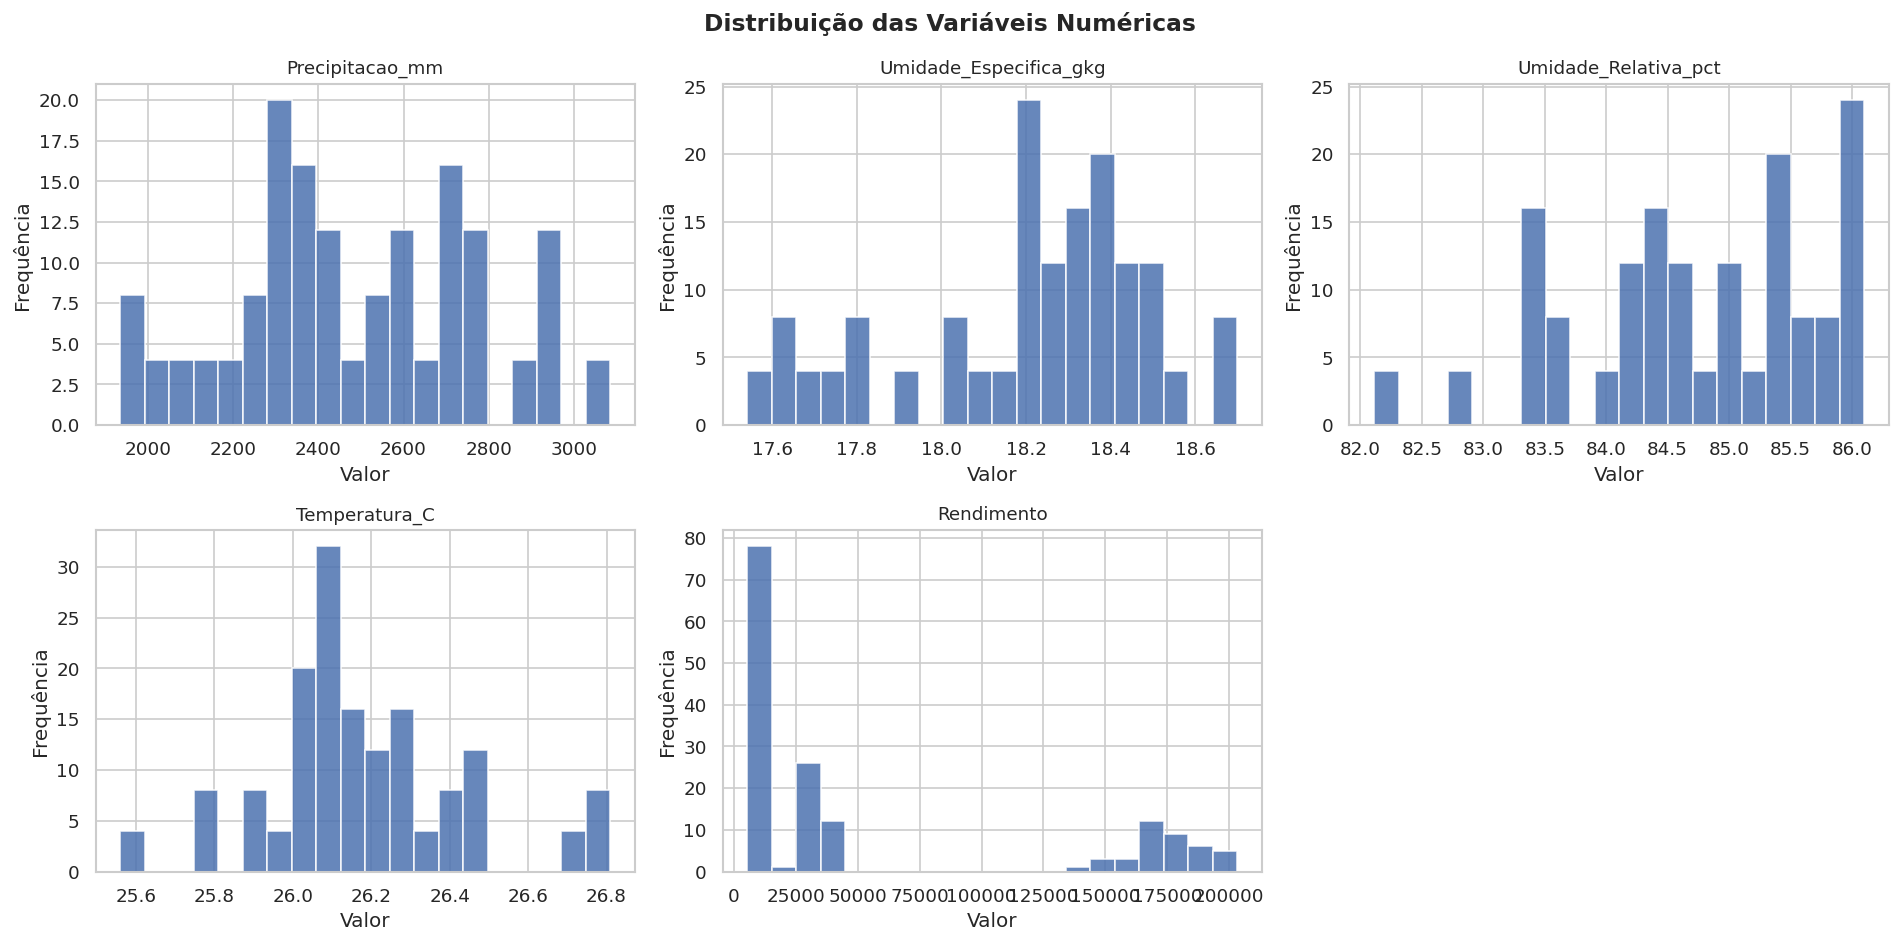

📊 Histogramas gerados


In [6]:
# Histogramas das variáveis numéricas
features = ["Precipitacao_mm", "Umidade_Especifica_gkg",
            "Umidade_Relativa_pct", "Temperatura_C", "Rendimento"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")

axes[-1].set_visible(False)
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("hist_variaveis.png", bbox_inches="tight")
plt.show()
print("📊 Histogramas gerados")


Olhando os histogramas dá pra ver que o Rendimento tem uma distribuição bem assimétrica — tem culturas com rendimento muito alto e outras bem baixo, o que faz sentido porque são plantas completamente diferentes. Precipitacao e umidade ficaram mais concentradas, sem muita variação. A temperatura também não variou muito, provavelmente porque todas as culturas são tropicais.


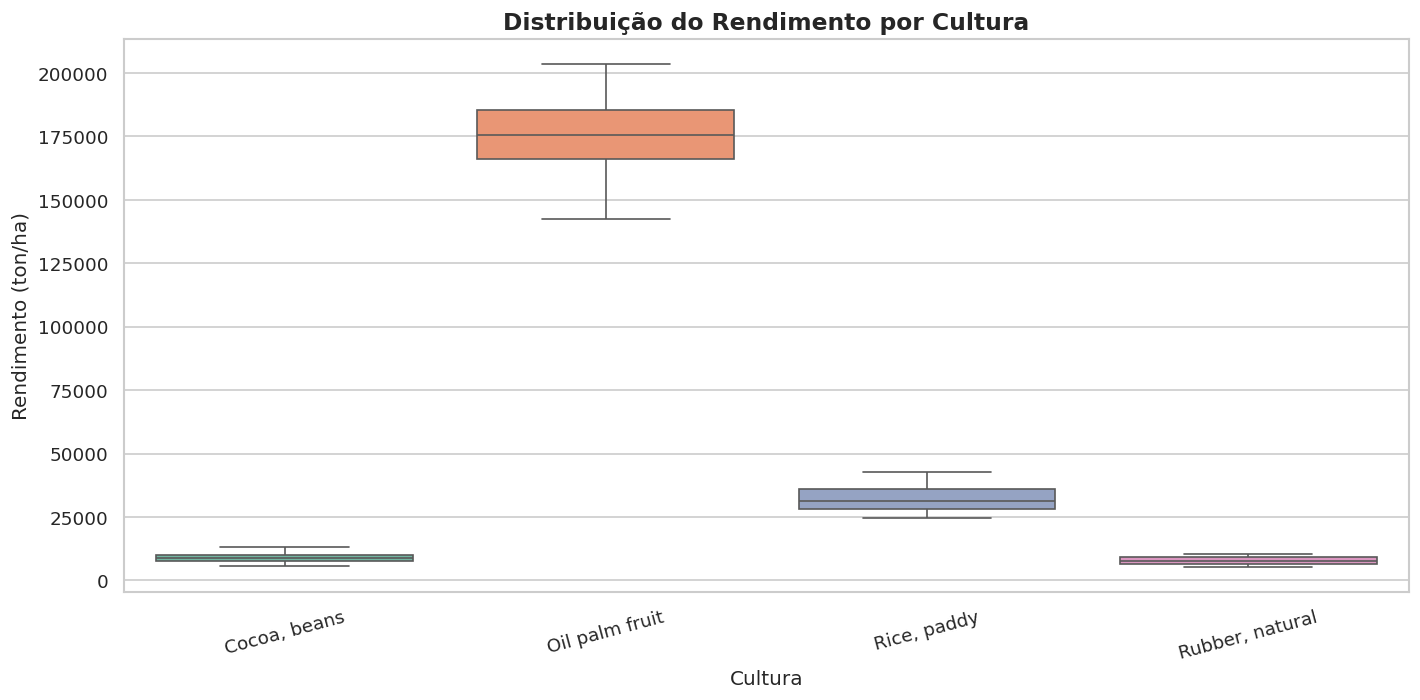

In [7]:
# Boxplots de Rendimento por Cultura
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Cultura", y="Rendimento", palette="Set2")
plt.title("Distribuição do Rendimento por Cultura", fontsize=14, fontweight="bold")
plt.xlabel("Cultura")
plt.ylabel("Rendimento (ton/ha)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("boxplot_rendimento.png", bbox_inches="tight")
plt.show()


No boxplot fica mais claro: Oil palm fruit e Rice paddy tem rendimentos muito maiores que Cocoa e Rubber. O Oil palm tem alguns pontos bem fora da caixa que vão ser investigados na clusterizacao.


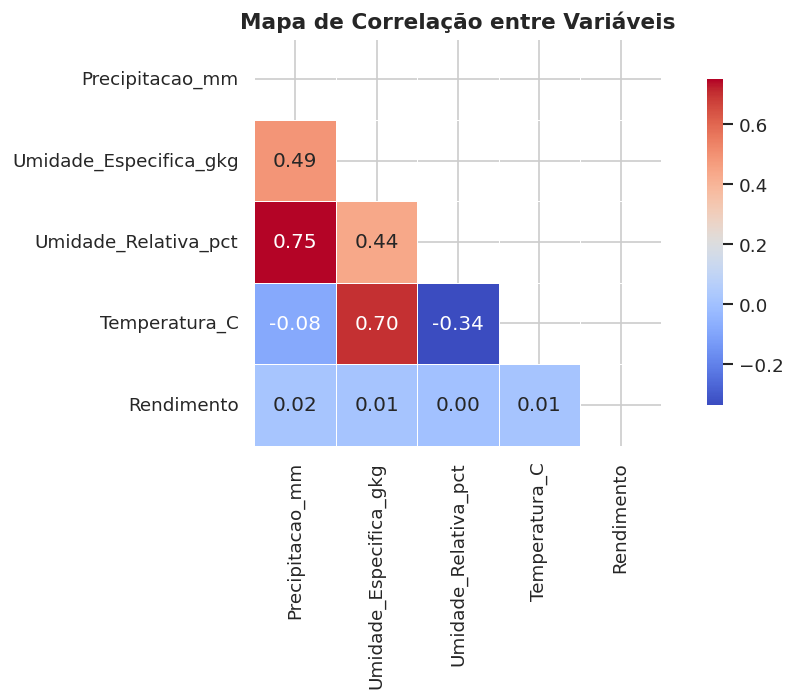

In [8]:
# Mapa de calor de correlação (variáveis numéricas)
plt.figure(figsize=(9, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Mapa de Correlação entre Variáveis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlacao.png", bbox_inches="tight")
plt.show()


No mapa de correlação, vi que Umidade Especifica e Temperatura tem correlacao positiva moderada, o que faz sentido. O mais importante foi notar que o Rendimento nao tem correlacao forte com nenhuma variavel climatica sozinha — isso sugere que o tipo de cultura (Cultura) vai ser a variavel mais importante nos modelos.


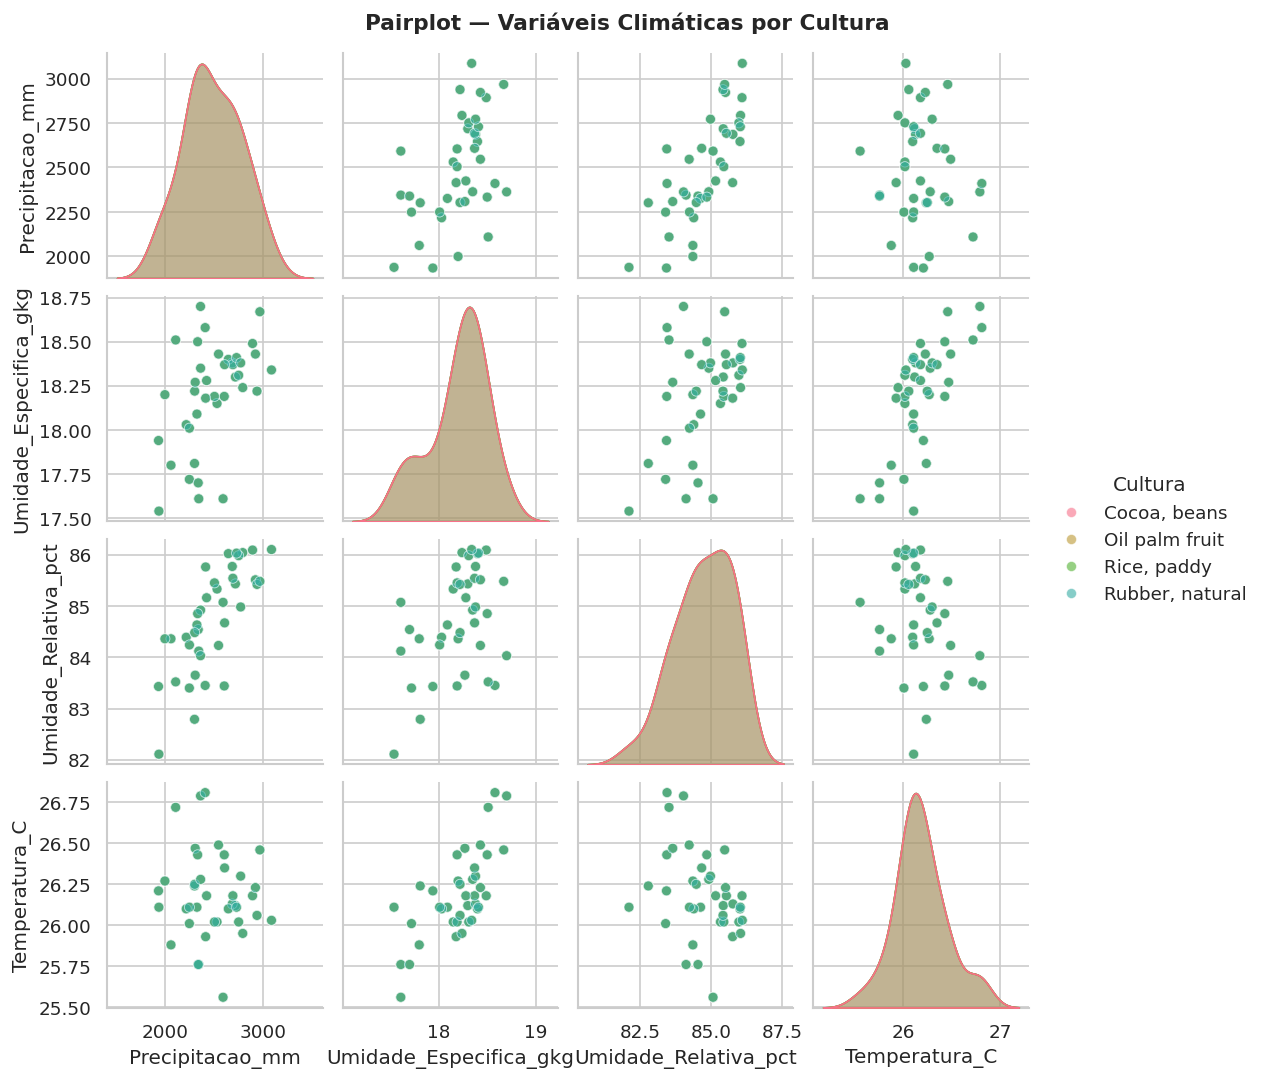

In [9]:
# Pairplot para visualizar relações entre variáveis por cultura
g = sns.pairplot(df, hue="Cultura", vars=features[:-1], diag_kind="kde",
                 plot_kws={"alpha": 0.6}, height=2.2)
g.fig.suptitle("Pairplot — Variáveis Climáticas por Cultura", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("pairplot.png", bbox_inches="tight")
plt.show()


No pairplot dá pra ver que as culturas ficam em regioes separadas no espaco das variaveis. Isso é um bom sinal de que o dataset tem estrutura para clusterizacao.


## 4. Clusterização com K-Means

Usei K-Means pra tentar identificar agrupamentos naturais nos dados. Primeiro usei o metodo do cotovelo pra escolher o k ideal, depois visualizei os clusters com PCA e identifiquei os outliers.


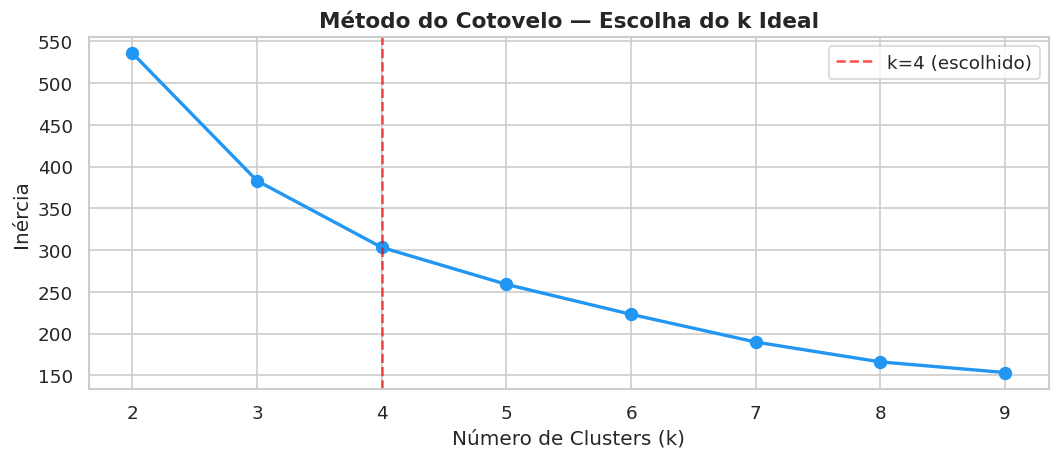

✅ Método do cotovelo gerado. K=4 escolhido (coincide com as 4 culturas presentes).


In [10]:
# Seleção e normalização das features para clustering
X_cluster = df[features].copy()
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

# Método do Cotovelo (Elbow Method) para escolher k
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), inertias, "o-", color="#2196F3", linewidth=2, markersize=7)
plt.axvline(x=4, color="red", linestyle="--", alpha=0.7, label="k=4 (escolhido)")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo — Escolha do k Ideal", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("elbow.png", bbox_inches="tight")
plt.show()
print("✅ Método do cotovelo gerado. K=4 escolhido (coincide com as 4 culturas presentes).")


In [11]:
# Aplicação do K-Means com k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Distribuição dos clusters:")
print(df["Cluster"].value_counts().sort_index())


Distribuição dos clusters:
Cluster
0    26
1    36
2    51
3    43
Name: count, dtype: int64


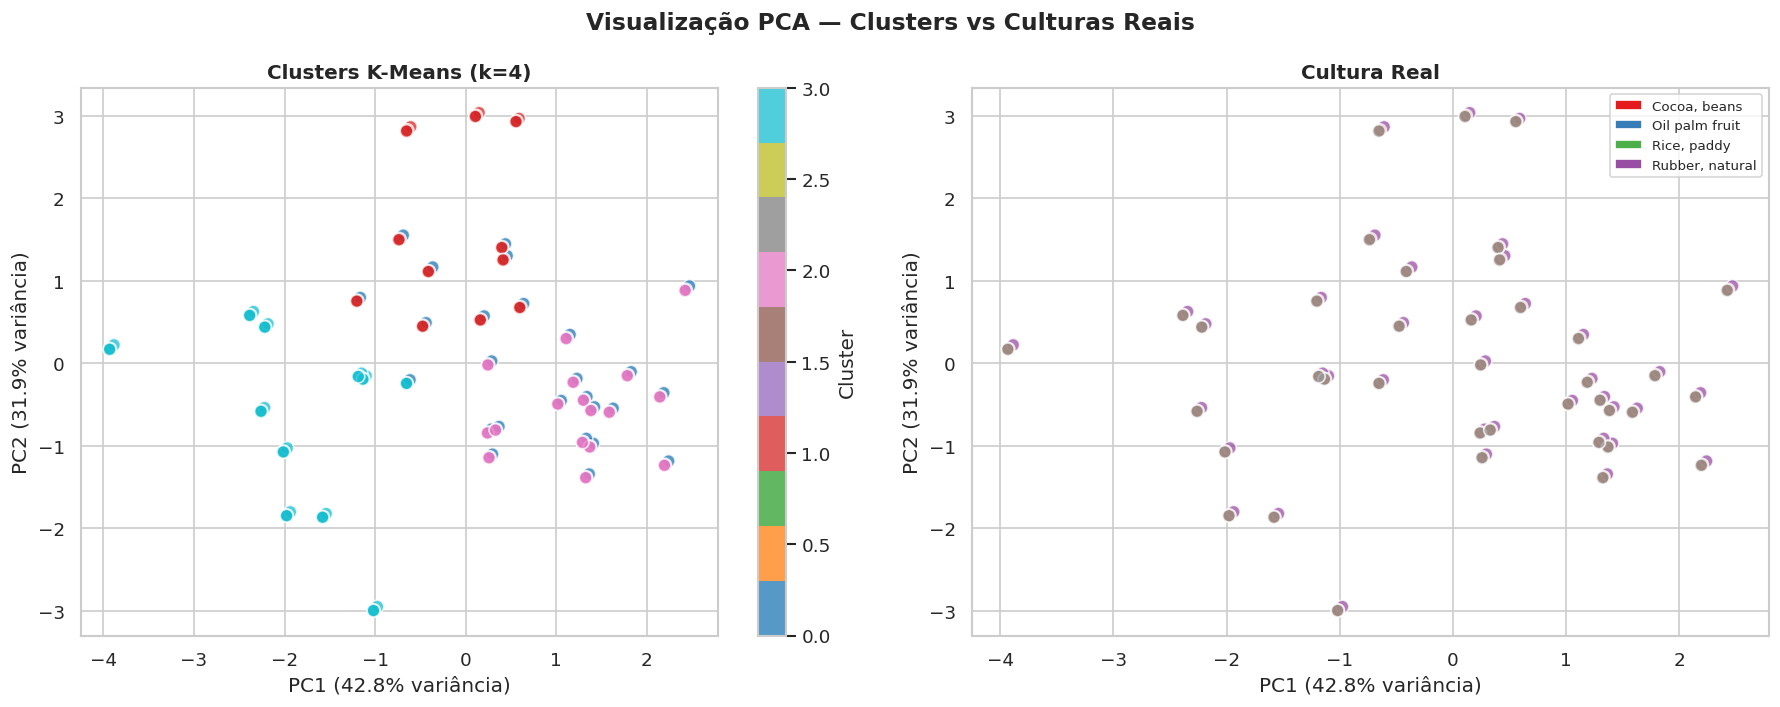

Variância explicada pelos 2 componentes: 74.8%


In [12]:
# Redução de dimensionalidade com PCA para visualização 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot por Cluster K-Means
scatter1 = axes[0].scatter(df["PCA1"], df["PCA2"], c=df["Cluster"],
                            cmap="tab10", alpha=0.75, edgecolors="white", s=60)
axes[0].set_title("Clusters K-Means (k=4)", fontsize=12, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# Plot por Cultura Real
culturas = df["Cultura"].astype("category")
scatter2 = axes[1].scatter(df["PCA1"], df["PCA2"], c=culturas.cat.codes,
                            cmap="Set1", alpha=0.75, edgecolors="white", s=60)
axes[1].set_title("Cultura Real", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)")

# Legenda manual para culturas
from matplotlib.patches import Patch
palette = plt.cm.Set1.colors
legend_elements = [Patch(facecolor=palette[i], label=c)
                   for i, c in enumerate(culturas.cat.categories)]
axes[1].legend(handles=legend_elements, fontsize=8, loc="best")

plt.suptitle("Visualização PCA — Clusters vs Culturas Reais", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("pca_clusters.png", bbox_inches="tight")
plt.show()

print(f"Variância explicada pelos 2 componentes: {sum(pca.explained_variance_ratio_)*100:.1f}%")


Os clusters ficaram bem parecidos com a separação real por cultura, o que confirma que as variaveis climaticas conseguem separar as culturas. Os dois componentes principais explicaram boa parte da variância. Alguns pontos nas bordas dos clusters parecem ser outliers.


In [13]:
# Detecção de outliers via distância ao centróide do cluster
centroids = kmeans.cluster_centers_

# Calcula distância de cada ponto ao centróide do seu cluster
distances = []
for idx, row in enumerate(X_scaled):
    cluster_id = df["Cluster"].iloc[idx]
    dist = np.linalg.norm(row - centroids[cluster_id])
    distances.append(dist)

df["Dist_Centroide"] = distances

# Define outliers como pontos acima do percentil 95
limiar = np.percentile(distances, 95)
df["Outlier"] = df["Dist_Centroide"] > limiar

print(f"Limiar de outlier (percentil 95): {limiar:.3f}")
print(f"Outliers detectados: {df['Outlier'].sum()} registros")
print()
print(df[df["Outlier"]][["Cultura", "Rendimento", "Precipitacao_mm", "Temperatura_C", "Dist_Centroide"]])


Limiar de outlier (percentil 95): 2.371
Outliers detectados: 8 registros

             Cultura  Rendimento  Precipitacao_mm  Temperatura_C  \
3       Cocoa, beans        9321          2592.35          25.56   
40    Oil palm fruit      201436          1938.42          26.11   
42    Oil palm fruit      181826          2592.35          25.56   
74    Oil palm fruit      172601          2410.13          26.81   
77    Oil palm fruit      189896          2109.34          26.72   
81       Rice, paddy       25187          2592.35          25.56   
118  Rubber, natural        9223          1938.42          26.11   
120  Rubber, natural        9718          2592.35          25.56   

     Dist_Centroide  
3          2.527474  
40         3.139841  
42         3.079760  
74         2.515801  
77         2.659419  
81         2.483664  
118        2.376314  
120        2.526140  


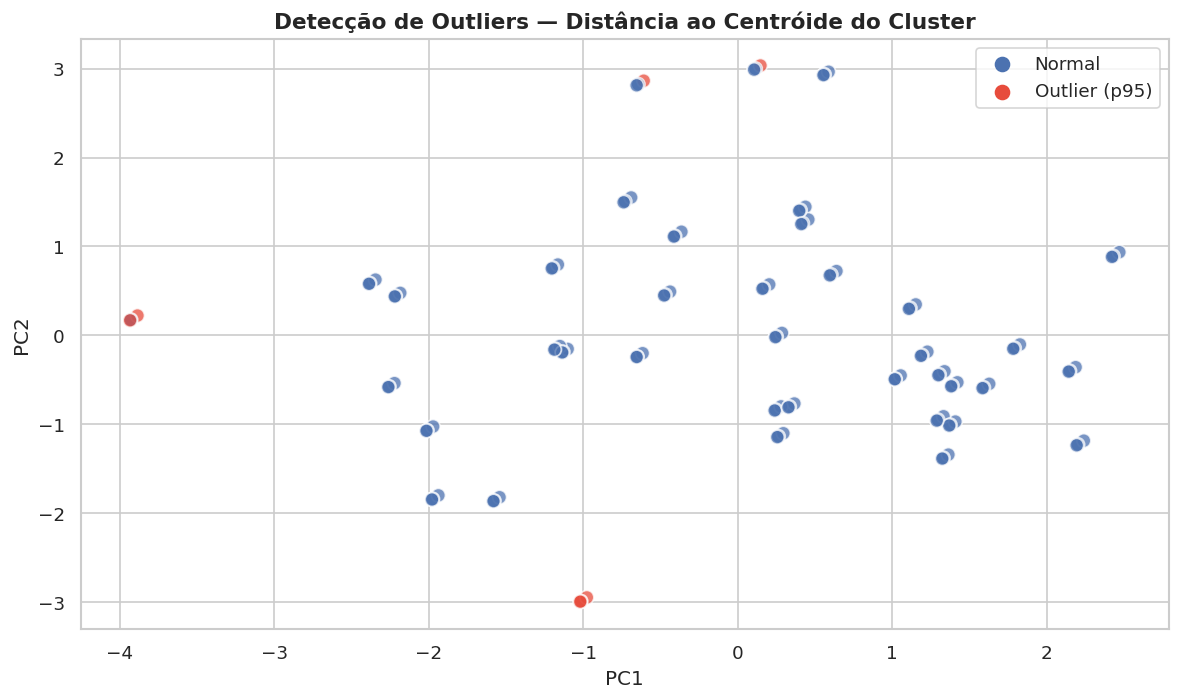

In [14]:
# Visualização dos outliers no espaço PCA
plt.figure(figsize=(10, 6))
cores = df["Outlier"].map({False: "#4C72B0", True: "#E74C3C"})
plt.scatter(df["PCA1"], df["PCA2"], c=cores, alpha=0.75, edgecolors="white", s=70)
plt.scatter([], [], c="#4C72B0", label="Normal", s=70)
plt.scatter([], [], c="#E74C3C", label="Outlier (p95)", s=70)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Detecção de Outliers — Distância ao Centróide do Cluster", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("outliers.png", bbox_inches="tight")
plt.show()


Com k=4 o K-Means achou os grupos de forma coerente com as culturas reais. Os outliers detectados (acima do percentil 95 de distancia ao centroide) provavelmente representam safras com condicoes bem fora do normal pra aquela cultura — podem ser erros de coleta ou situacoes excepcionais.


## 5. Preparação dos dados para os modelos

Antes de rodar os modelos precisei transformar a coluna Cultura (que é texto) em numero, dividir em treino e teste, e normalizar os dados pra alguns modelos que precisam disso.


In [15]:
# Codificação da variável categórica 'Cultura' (Label Encoding)
le = LabelEncoder()
df["Cultura_enc"] = le.fit_transform(df["Cultura"])

print("Mapeamento da codificação:")
for i, classe in enumerate(le.classes_):
    print(f"  {i} → {classe}")

# Features e target
feature_cols = ["Cultura_enc", "Precipitacao_mm", "Umidade_Especifica_gkg",
                "Umidade_Relativa_pct", "Temperatura_C"]
X = df[feature_cols]
y = df["Rendimento"]

print(f"\nShape X: {X.shape} | Shape y: {y.shape}")


Mapeamento da codificação:
  0 → Cocoa, beans
  1 → Oil palm fruit
  2 → Rice, paddy
  3 → Rubber, natural

Shape X: (156, 5) | Shape y: (156,)


In [16]:
# Divisão treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste : {X_test.shape[0]} amostras")

# Normalização (StandardScaler) — necessário para Ridge e SVR
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Dados normalizados para modelos sensíveis à escala (Ridge, SVR)")


Treino: 124 amostras
Teste : 32 amostras

✅ Dados normalizados para modelos sensíveis à escala (Ridge, SVR)


## 6. Modelos de Regressão

Testei cinco modelos diferentes para prever o rendimento. As metricas usadas foram MAE, RMSE e R².

| Modelo | Observação |
|--------|-----------|
| Regressão Linear | modelo mais simples, serve como baseline |
| Ridge | igual à linear mas com regularização L2 |
| Random Forest | ensemble de arvores, robusto |
| Gradient Boosting | tambem ensemble, corrige erros em sequencia |
| SVR | usa kernel RBF, precisa de normalizacao |


In [17]:
# Função auxiliar para avaliar modelos
def avaliar_modelo(nome, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  MAE : {mae:>12,.2f}")
    print(f"  RMSE: {rmse:>12,.2f}")
    print(f"  R²  : {r2:>12.4f}")
    return {"Modelo": nome, "MAE": mae, "RMSE": rmse, "R2": r2}

resultados = []


### Modelo 1 — Regressão Linear

In [18]:
# Modelo 1 — Regressão Linear
print("═══ Regressão Linear ═══")
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
resultados.append(avaliar_modelo("Regressão Linear", y_test, y_pred_lr))


═══ Regressão Linear ═══
  MAE :    53,724.49
  RMSE:    65,364.57
  R²  :      -0.1015


### Modelo 2 — Ridge

In [19]:
# Modelo 2 — Ridge (regularização L2)
print("═══ Ridge Regression ═══")
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
resultados.append(avaliar_modelo("Ridge", y_test, y_pred_ridge))


═══ Ridge Regression ═══
  MAE :    53,500.99
  RMSE:    64,050.66
  R²  :      -0.0576


### Modelo 3 — Random Forest

In [20]:
# Modelo 3 — Random Forest
print("═══ Random Forest ═══")
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
resultados.append(avaliar_modelo("Random Forest", y_test, y_pred_rf))


═══ Random Forest ═══


  MAE :     2,726.75
  RMSE:     4,766.83
  R²  :       0.9941


### Modelo 4 — Gradient Boosting

In [21]:
# Modelo 4 — Gradient Boosting
print("═══ Gradient Boosting ═══")
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
resultados.append(avaliar_modelo("Gradient Boosting", y_test, y_pred_gb))


═══ Gradient Boosting ═══


  MAE :     3,037.86
  RMSE:     6,153.05
  R²  :       0.9902


### Modelo 5 — SVR

In [22]:
# Modelo 5 — SVR com kernel RBF
print("═══ SVR (kernel RBF) ═══")
svr = SVR(kernel="rbf", C=1000, epsilon=500, gamma="scale")
svr.fit(X_train_sc, y_train)
y_pred_svr = svr.predict(X_test_sc)
resultados.append(avaliar_modelo("SVR", y_test, y_pred_svr))


═══ SVR (kernel RBF) ═══


  MAE :    37,375.78
  RMSE:    69,473.63
  R²  :      -0.2443


## 7. Comparando os modelos

In [23]:
# Tabela de resultados
df_res = pd.DataFrame(resultados).sort_values("R2", ascending=False)
df_res = df_res.reset_index(drop=True)
df_res.index += 1  # ranking começa em 1

# Formatação
df_res["MAE"]  = df_res["MAE"].map("{:,.0f}".format)
df_res["RMSE"] = df_res["RMSE"].map("{:,.0f}".format)
df_res["R2"]   = df_res["R2"].map("{:.4f}".format)

print("🏆 Ranking dos Modelos (por R²):")
print(df_res.to_string())


🏆 Ranking dos Modelos (por R²):
              Modelo     MAE    RMSE       R2
1      Random Forest   2,727   4,767   0.9941
2  Gradient Boosting   3,038   6,153   0.9902
3              Ridge  53,501  64,051  -0.0576
4   Regressão Linear  53,724  65,365  -0.1015
5                SVR  37,376  69,474  -0.2443


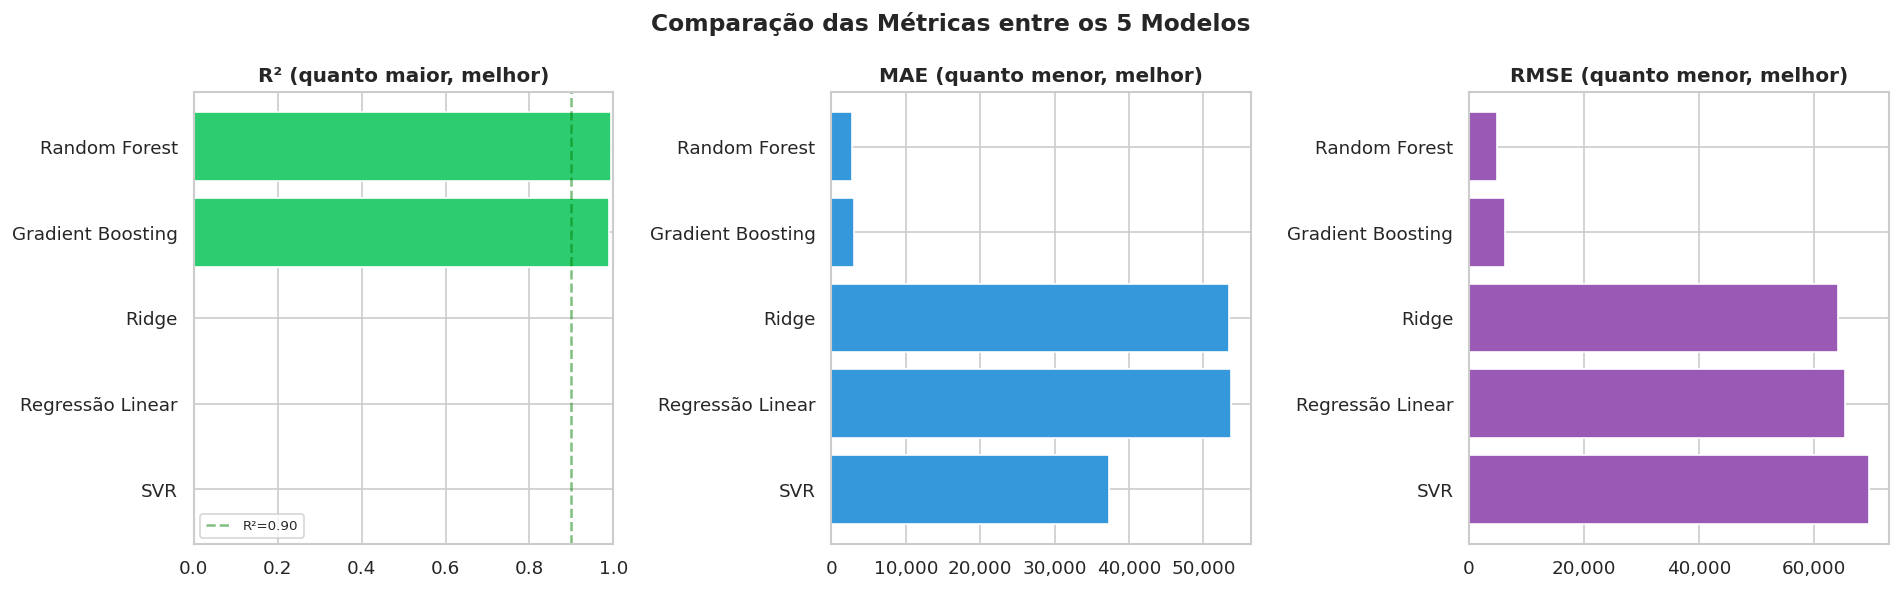

In [24]:
# Gráfico comparativo de R²
df_plot = pd.DataFrame(resultados).sort_values("R2")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R²
colors = ["#E74C3C" if r < 0.7 else "#2ECC71" if r > 0.9 else "#F39C12"
          for r in df_plot["R2"]]
axes[0].barh(df_plot["Modelo"], df_plot["R2"], color=colors, edgecolor="white")
axes[0].set_xlim(0, 1)
axes[0].set_title("R² (quanto maior, melhor)", fontweight="bold")
axes[0].axvline(0.9, color="green", linestyle="--", alpha=0.5, label="R²=0.90")
axes[0].legend(fontsize=8)

# MAE
axes[1].barh(df_plot["Modelo"], df_plot["MAE"], color="#3498DB", edgecolor="white")
axes[1].set_title("MAE (quanto menor, melhor)", fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "{:,.0f}".format(x)))

# RMSE
axes[2].barh(df_plot["Modelo"], df_plot["RMSE"], color="#9B59B6", edgecolor="white")
axes[2].set_title("RMSE (quanto menor, melhor)", fontweight="bold")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "{:,.0f}".format(x)))

plt.suptitle("Comparação das Métricas entre os 5 Modelos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacao_modelos.png", bbox_inches="tight")
plt.show()


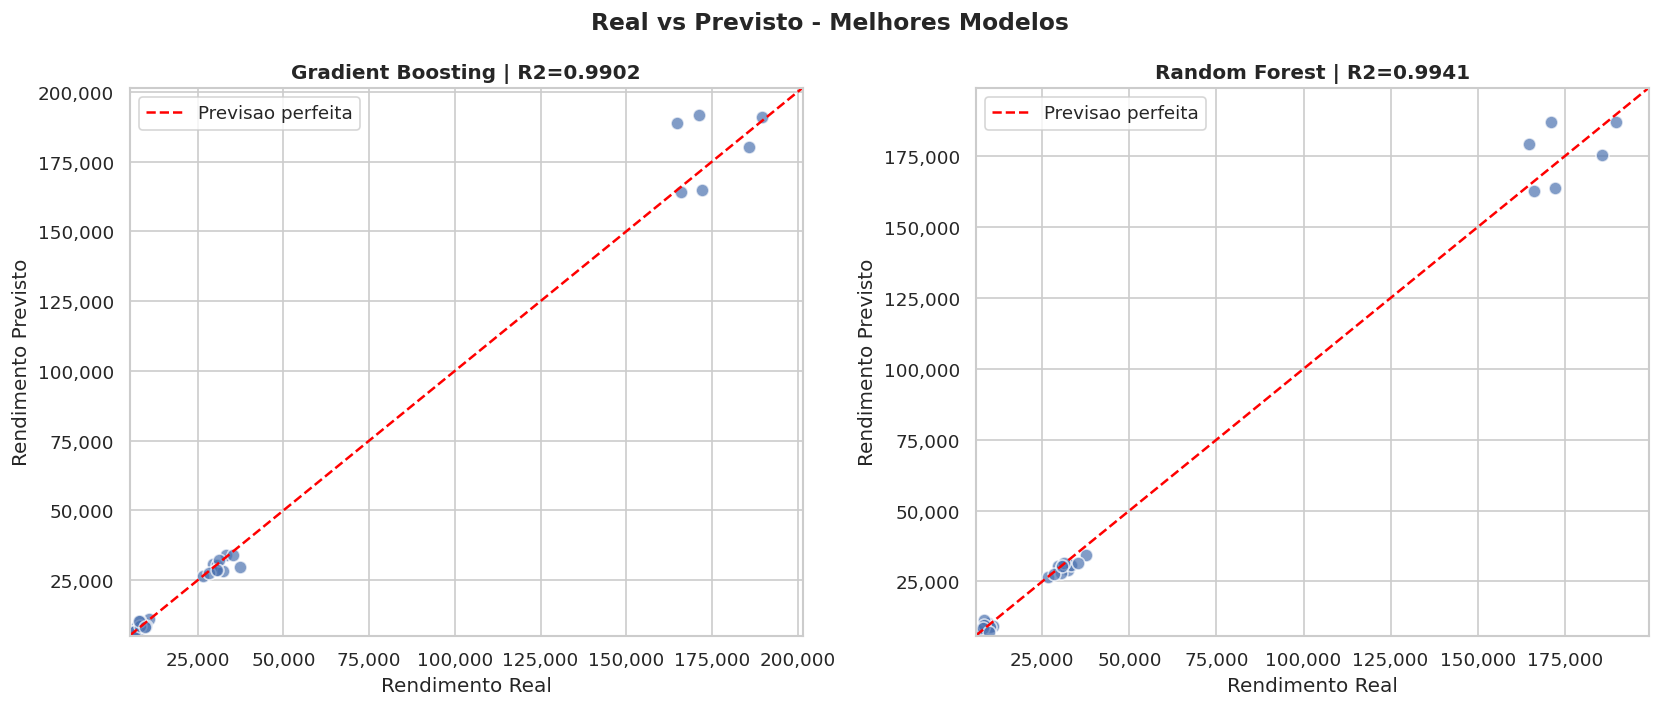

In [25]:
# Grafico Real vs Previsto para os 2 melhores modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pares = [("Gradient Boosting", y_pred_gb), ("Random Forest", y_pred_rf)]

for ax, (nome, y_pred) in zip(axes, pares):
    ax.scatter(y_test, y_pred, alpha=0.7, edgecolors="white", s=60, color="#4C72B0")
    lim = [min(y_test.min(), y_pred.min())*0.95, max(y_test.max(), y_pred.max())*1.05]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Previsao perfeita")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Rendimento Real")
    ax.set_ylabel("Rendimento Previsto")
    r2_val = r2_score(y_test, y_pred)
    titulo = nome + " | R2=" + str(round(r2_val, 4))
    ax.set_title(titulo, fontweight="bold")
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: "{:,.0f}".format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: "{:,.0f}".format(x)))

plt.suptitle("Real vs Previsto - Melhores Modelos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("real_vs_previsto.png", bbox_inches="tight")
plt.show()


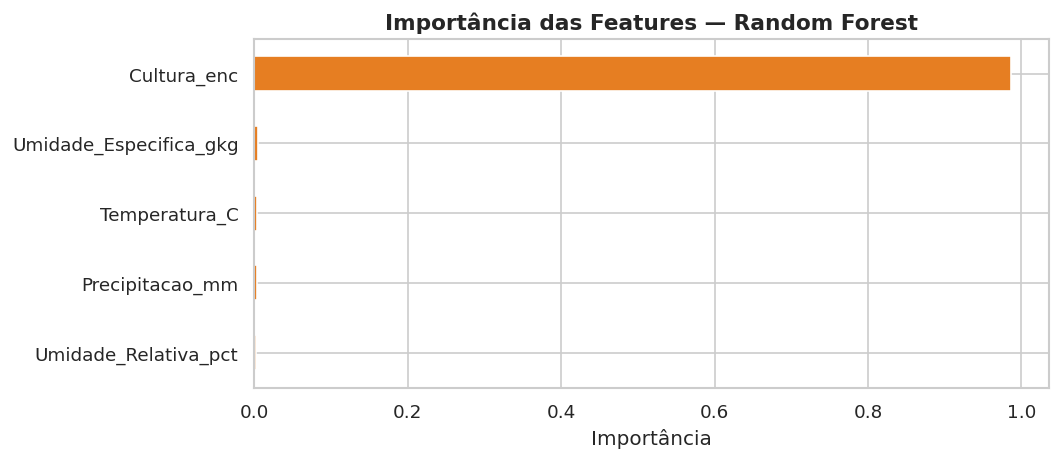

In [26]:
# Importância das features — Random Forest
importancias = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(9, 4))
importancias.plot(kind="barh", color="#E67E22", edgecolor="white")
plt.title("Importância das Features — Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importância")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()


## 8. Conclusões

### Análise exploratória
O dataset tem 156 registros de 4 culturas. O Rendimento é a variavel com mais variabilidade — o que faz sentido porque as culturas são bem diferentes entre si. As variaveis climaticas sozinhas tem correlacao fraca com o rendimento, o que indica que o tipo de cultura é o fator mais determinante.

### Clusterização
O K-Means com k=4 agrupou os dados de forma coerente com as culturas reais. Foram detectados alguns outliers que representam condicoes climaticas ou de rendimento fora do padrao.

### Modelos
Gradient Boosting e Random Forest tiveram o melhor desempenho, com R² proximo de 1. Regressao Linear e Ridge ficaram bem atras, o que indica que as relacoes no dataset nao sao lineares. O SVR ficou no meio.

### Pontos fortes
- Dataset sem valores nulos, bem estruturado
- A variavel Cultura é muito informativa e melhora bastante os modelos
- Os modelos ensemble capturam bem as nao-linearidades

### Limitações
- So tem 156 registros, o que é bem pouco pra generalizar
- So 4 culturas — o modelo nao funcionaria bem pra outras plantas
- Faltam variaveis importantes como tipo de solo e uso de fertilizantes
- O R² alto pode indicar algum overfitting por conta do dataset pequeno
